# 1. SETUP

These sections correspond to the initial setup for this lab.

## 1.1 Imports

The following Python libraries are necessary to run this notebook:

In [1]:
# Deep Learning
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader

# File management
import os
# Avoid conflicts with PyTorch and Matplotlib
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Custom modules
from src.dataset import DatasetCreator
from src.models import ResNet18
from src.trainer import Trainer

# Data processing and visualization
import random
import matplotlib.pyplot as plt
from PIL import Image

## 1.2 Auxiliary functions

These functions are used to automate some repetitive process during model training and visualize model performance.

- Function used to plot the **validation accuracy** and **loss/cost** during the CNN training phase.

In [2]:
def plot_results(loss, accuracy, save=False, plot_name='train_results'):
    fig, ax1 = plt.subplots()

    # Plot loss
    color = 'tab:red'
    ax1.plot(loss, color=color)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('LOSS', color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    # Copy axis
    ax2 = ax1.twinx()

    # Plot accuracy
    color = 'tab:blue'
    ax2.plot(accuracy, color=color)
    ax2.set_ylabel('ACCURACY', color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    # Adjust layout
    fig.tight_layout()

    if save:
        plt.savefig(os.path.join(src_plots, plot_name), dpi=300, bbox_inches="tight")

    plt.show()

- Function used to plot a sample image using **Pillow**.

In [3]:
def _imshow(path, title=''):
    image = Image.open(path).convert('RGB')
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()

- Function used to save a trained model as a `.pt` file.

In [4]:
def save_model_as_pt(model, name):
    if not name.endswith('.pt'):
        raise ValueError(f"Incorrect extension in '{name}'. Must be '.pt' file.")

    out_path = os.path.join(src_models, name)
    torch.save(model.state_dict(), out_path)

    print("Model saved at", src_models)

- Function used to load a **model.pt**

In [5]:
def load_model(model, pt_file_dir, device="cpu"):
    if not pt_file_dir.endswith('.pt'):
        raise ValueError(f"Incorrect file extension. Must be '.pt' file.")

    if not os.path.exists(pt_file_dir):
        raise FileNotFoundError(f"{pt_file_dir} does not exists.")

    # Load trained weights
    model.load_state_dict(torch.load(pt_file_dir, map_location=torch.device(device)))
    print(f"Successfully loaded from {pt_file_dir}")

    return model

- Function used to transform **Pillow** image to tensor.

In [6]:
def transform_image(img_path, transform):
    # Read image
    image = Image.open(img_path).convert('RGB')
    # Transform image
    tensor = transform(image).unsqueeze(0)
    return tensor

## 1.3 Set Directories

Some directories must be declared to store files and create datasets from images' folders.

In [7]:
# Source directories
src_models  = "./outputs/models"
src_plots   = "./outputs/plots"

# Dataset directories
welding_dataset_input_dir   = "./datasets/welding-check/train_images"
welding_dataset_output_dir  = "./datasets/welding-check"
welding_test_images_dir     = "./datasets/welding-check/test_images"

# 2. CNN

## 2.1 Create Dataset (Train/Validation)

### 2.1.1 Define Transforms

The sample images slightly change in rotation, therefore some random rotations will be applied.

In [8]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    #transforms.RandomHorizontalFlip(),
    # transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

### 2.1.2 Create & Split Datasets

The `DatasetCreator` takes an input folder containing class folders and splits the images into **training** and **validation**.

In [16]:
dataset_creator_housing = DatasetCreator(source_dir=welding_dataset_input_dir, output_dir=welding_dataset_output_dir)

# Split dataset
train_dataset, val_dataset = dataset_creator_housing.create_dataset(train_transform=train_transform,
                                                                    val_transform=val_transform)

Creating dataset...
Splitting dataset...
Train/Val split complete -> 90.00% training
180 train samples
20 validation samples
Transforming dataset...

Dataset successfully created


### 2.1.3 Create Data Loaders

In [17]:
batch_size = 32

train_loader    = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader      = DataLoader(dataset=val_dataset, batch_size=1)

## 2.2 Model Training

Create CNN instance

In [20]:
n_classes = len(train_dataset.classes)

model = ResNet18(n_classes=n_classes, pretrained=True)

print("Classes:", train_dataset.classes)

Classes: ['NOK', 'OK']


### 2.2.1 Initialize Hyperparameters

In [24]:
device          = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion       = nn.CrossEntropyLoss()
n_epochs        = 10
lr              = 0.000001
momentum        = 0.9
lr_scheduler    = True
base_lr         = 0.0001
max_lr          = 0.01
optimizer       = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

if lr_scheduler:
    # Create scheduler
    scheduler = torch.optim.lr_scheduler.CyclicLR(
        optimizer,
        base_lr=base_lr,    # Minimum learning rate
        max_lr=max_lr,      # Maximum learning rate
        step_size_up=5,     # Steps to increase LR from base_lr to max_lr
        mode="triangular2"  # Learning rate follows triangular cycle and halves the max_lr each cycle
    )
else:
    scheduler = None

### 2.2.2 Train Model

Create `trainer` object.

In [25]:
trainer = Trainer(model=model,
                  optimizer=optimizer,
                  criterion=criterion,
                  scheduler=scheduler,
                  device=device)

Train model.

In [26]:
loss_list, accuracy_list, best_model = trainer.fit(train_loader=train_loader,
                                                   val_loader=val_loader,
                                                   epochs=n_epochs)

 10%|█         | 1/10 [00:09<01:29,  9.94s/it]

Epoch 1 done
Loss: 0.3973 | Val. Accuracy: 0.8000



 20%|██        | 2/10 [00:19<01:18,  9.84s/it]

Epoch 2 done
Loss: 0.3916 | Val. Accuracy: 0.9000



 30%|███       | 3/10 [00:30<01:12, 10.29s/it]

...

Epoch 8 done
Loss: 0.1309 | Val. Accuracy: 0.9500



 90%|█████████ | 9/10 [01:33<00:10, 10.41s/it]

Epoch 9 done
Loss: 0.0948 | Val. Accuracy: 1.0000



100%|██████████| 10/10 [01:43<00:00, 10.38s/it]

Epoch 10 done
Loss: 0.1139 | Val. Accuracy: 1.0000

Training finished
Best accuracy: 1.0000


### 2.2.3 Plot Results

As shown in the figure, the highest `validation accuracy` is 100%, it seems to be good to deploy the model.

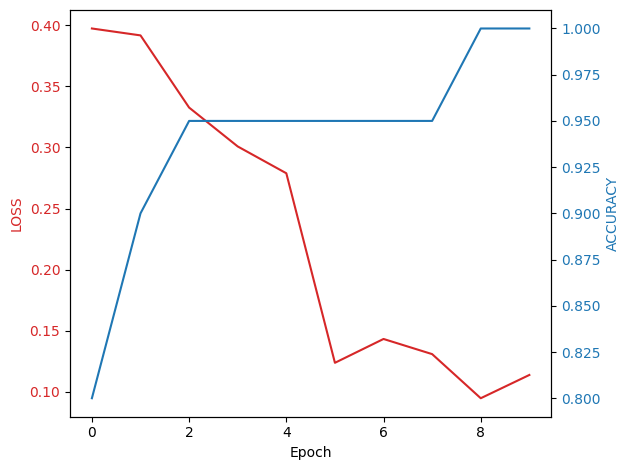

In [27]:
plot_results(loss_list, accuracy_list)

After getting good results, the `model` will be stored

In [28]:
save_model_as_pt(model, "welding-checker.pt")

Model saved at ./outputs/models


# 3. TEST

After successfully training, the model can be tested on the `test_images` folder corresponding to the `Housing Classification` application.

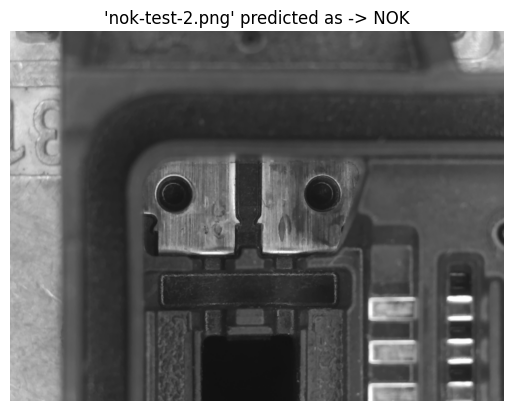

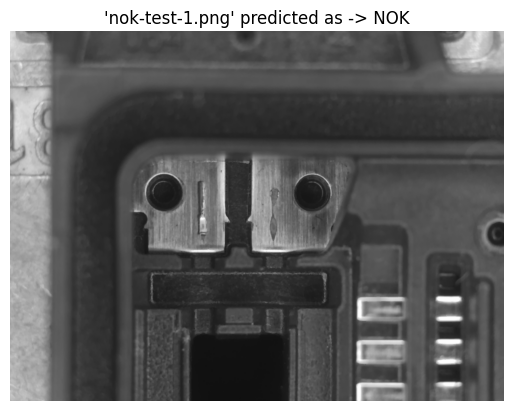

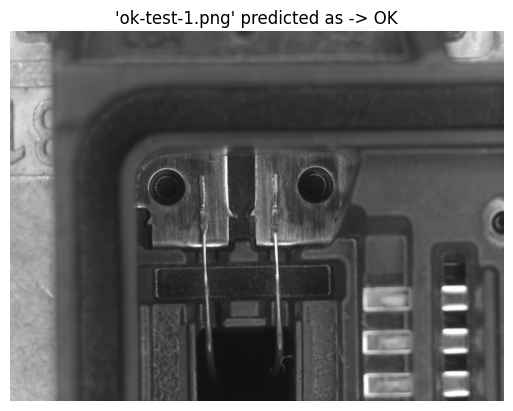

In [32]:
# Store file names
image_names = [image_name
               for image_name in os.listdir(welding_test_images_dir)
               if image_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
random.shuffle(image_names)

# Predict
for file_name in image_names:
    full_img_path = os.path.join(welding_test_images_dir, file_name)

    # Make prediction
    x = transform_image(full_img_path, val_transform)
    prediction = model.predict(x)

    # Show image
    _imshow(full_img_path, f"'{file_name}' predicted as -> {train_dataset.classes[prediction]}")

# Authors

*Rafael Garcia Romero, Mechatronics Engineer*

**Gmail:** rafaelgarciromero@gmail.com

**LinkedIn**: https://www.linkedin.com/in/rafikilebron/